# 📊 Telecom Customer Churn Analysis & Retention Strategy
**Author:** Atulukwu Sunday Idenyi  
**Objective:** Identify root causes for 1,869 churned accounts and provide a predictive roadmap to protect £137K in monthly revenue.

---
### 🛠️ The Tech Stack
* **Language:** Python 3.x
* **Libraries:** Pandas (Data Wrangling), Seaborn/Matplotlib (Visualization), Scikit-Learn (Machine Learning)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('telecomchurn.csv')

# View the first 5 rows to confirm it loaded correctly
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 41 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

In [3]:
# 1. Handling the 'Total Charges' Trap
# 'coerce' turns empty strings into NaN (nulls) so we can math them
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# 2. Fill missing Total Charges with 0 
# (These are the 454 'Joined' customers who haven't been billed yet)
df['Total Charges'] = df['Total Charges'].fillna(0)

# 3. Create a Binary Target for Churn
# This turns 'Customer Status' into 1s (Churned) and 0s (Stayed/Joined)
df['Is_Churned'] = df['Customer Status'].apply(lambda x: 1 if x == 'Churned' else 0)

# 4. Verify the transformation
print(df[['Customer Status', 'Is_Churned', 'Total Charges']].head())

  Customer Status  Is_Churned  Total Charges
0          Stayed           0         593.30
1          Stayed           0         542.40
2         Churned           1         280.85
3         Churned           1        1237.85
4         Churned           1         267.40


# Objective 1: Performance Gap

In [4]:
# Create Tenure Buckets to match our visual findings
def get_tenure_group(tenure):
    if tenure <= 6:
        return '0-6 Months (High Risk)'
    elif tenure <= 24:
        return '6-24 Months (Medium Risk)'
    else:
        return 'Over 2 Years (Loyal)'

df['Tenure_Group'] = df['Tenure in Months'].apply(get_tenure_group)

# Check the count of customers in each bucket
print(df['Tenure_Group'].value_counts())

Tenure_Group
Over 2 Years (Loyal)         3833
6-24 Months (Medium Risk)    1740
0-6 Months (High Risk)       1470
Name: count, dtype: int64


In [5]:
# 1. Count of Customers by Status
status_summary = df['Customer Status'].value_counts()

# 2. Revenue Summary (Sum of Monthly Charges)
revenue_summary = df.groupby('Customer Status')['Monthly Charge'].sum()

# 3. Calculate Churn Percentage (Total Churned / Total Customers)
total_customers = len(df)
churn_rate = (status_summary['Churned'] / total_customers) * 100

print(f"Total New Customers (Joined): {status_summary['Joined']}")
print(f"Total Churned Customers: {status_summary['Churned']}")
print(f"Overall Churn Rate: {churn_rate:.2f}%")
print("-" * 30)
print(f"Revenue Gained (Joined): £{revenue_summary['Joined']:,.2f}")
print(f"Revenue Lost (Churned): £{revenue_summary['Churned']:,.2f}")

Total New Customers (Joined): 454
Total Churned Customers: 1869
Overall Churn Rate: 26.54%
------------------------------
Revenue Gained (Joined): £19,420.30
Revenue Lost (Churned): £137,086.65


C:\Users\USER\AppData\Local\Temp\ipykernel_6340\1893660716.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=revenue_summary.index, y=revenue_summary.values, palette='viridis')


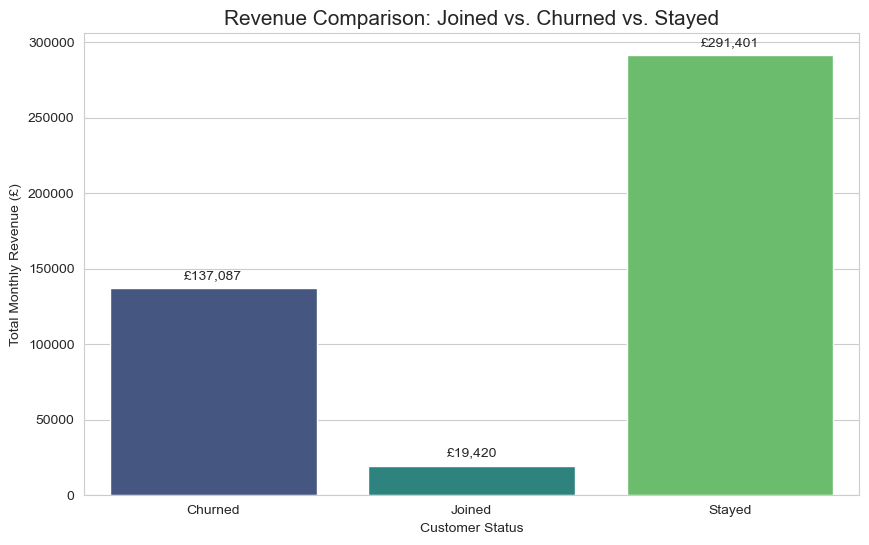

In [6]:
# Setting the style for your portfolio
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=revenue_summary.index, y=revenue_summary.values, palette='viridis')

# Adding labels to the bars for clarity
for p in ax.patches:
    ax.annotate(f'£{p.get_height():,.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title('Revenue Comparison: Joined vs. Churned vs. Stayed', fontsize=15)
plt.ylabel('Total Monthly Revenue (£)')
plt.show()

# Objective 2: Customer Profiling

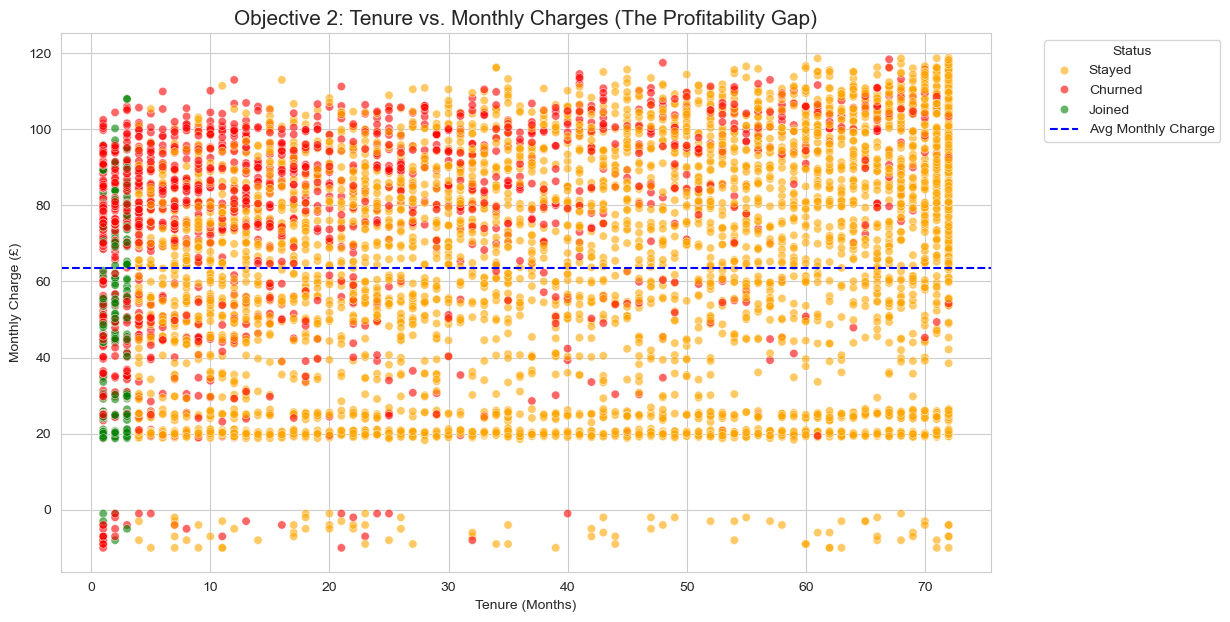

In [7]:
plt.figure(figsize=(12, 7))

# Creating the scatter plot
sns.scatterplot(data=df, 
                x='Tenure in Months', 
                y='Monthly Charge', 
                hue='Customer Status', 
                palette={'Churned': 'red', 'Stayed': 'orange', 'Joined': 'green'},
                alpha=0.6)

# Adding a horizontal line for Average Monthly Charge to show "High Value" threshold
plt.axhline(df['Monthly Charge'].mean(), color='blue', linestyle='--', label='Avg Monthly Charge')

plt.title('Objective 2: Tenure vs. Monthly Charges (The Profitability Gap)', fontsize=15)
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charge (£)')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [8]:
# Calculate average tenure and charges for each group
profile_stats = df.groupby('Customer Status')[['Tenure in Months', 'Monthly Charge']].mean()

print("Average Customer Profiles:")
print(profile_stats)

Average Customer Profiles:
                 Tenure in Months  Monthly Charge
Customer Status                                  
Churned                 17.979133       73.347592
Joined                   1.720264       42.775991
Stayed                  41.041525       61.737415


# Objective 3: Key Drivers (Root Cause)

In [9]:
# 1. Pivot Table for Internet Type vs. Churn
internet_churn = df.groupby('Internet Type')['Is_Churned'].mean() * 100

# 2. Pivot Table for Contract Type vs. Churn
contract_churn = df.groupby('Contract')['Is_Churned'].mean() * 100

print("Churn Rate by Internet Service:")
print(internet_churn.sort_values(ascending=False))
print("\nChurn Rate by Contract Type:")
print(contract_churn.sort_values(ascending=False))

Churn Rate by Internet Service:
Internet Type
Fiber Optic    40.724876
Cable          25.662651
DSL            18.583535
Name: Is_Churned, dtype: float64

Churn Rate by Contract Type:
Contract
Month-to-Month    45.844875
One Year          10.709677
Two Year           2.549124
Name: Is_Churned, dtype: float64


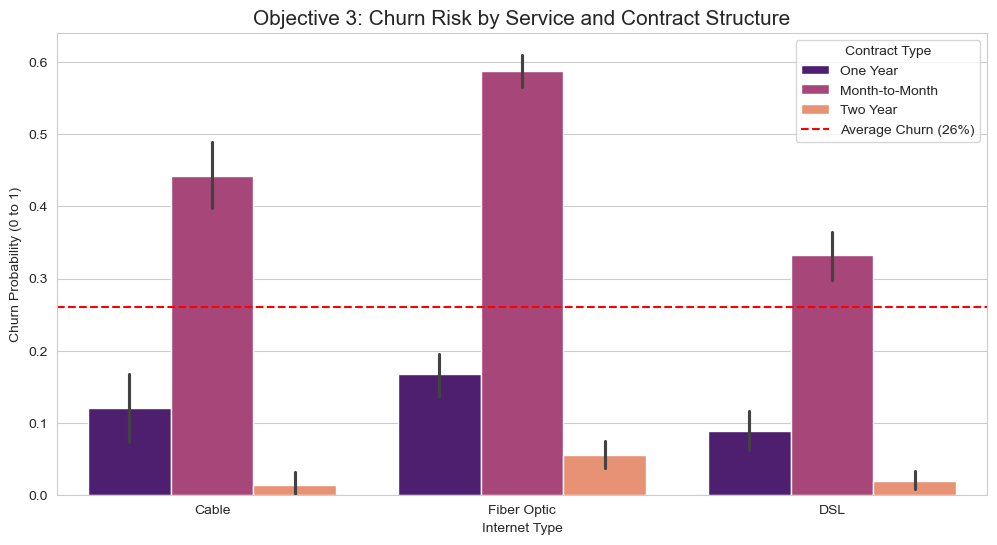

In [10]:
plt.figure(figsize=(12, 6))

# Visualizing the interaction between Contract and Internet Type
sns.barplot(data=df, x='Internet Type', y='Is_Churned', hue='Contract', palette='magma')

# Formatting for a professional look
plt.title('Objective 3: Churn Risk by Service and Contract Structure', fontsize=15)
plt.ylabel('Churn Probability (0 to 1)')
plt.axhline(0.26, color='red', linestyle='--', label='Average Churn (26%)') # Baseline
plt.legend(title='Contract Type')
plt.show()

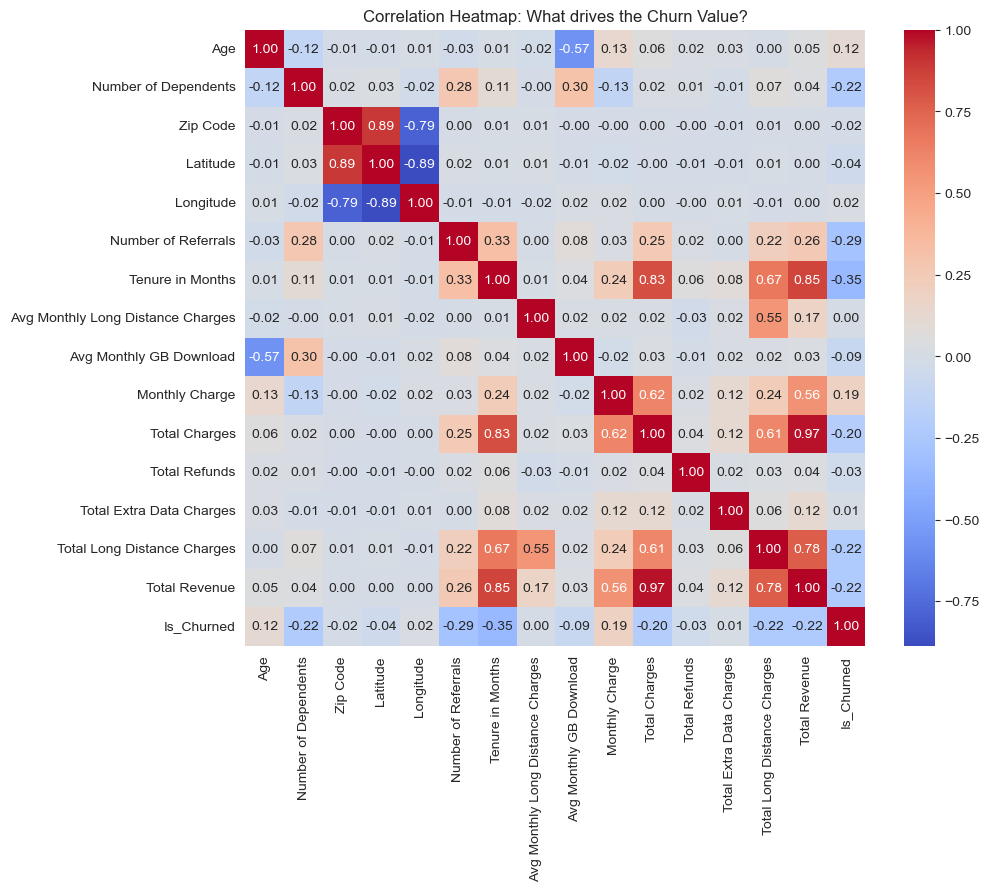

In [13]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: What drives the Churn Value?')
plt.show()

# Objective 4: The At-Risk Watchlist

In [14]:
# 1. Calculate the average monthly charge to define 'High Value'
avg_charge = df['Monthly Charge'].mean()

# 2. Filter for the 'At-Risk' Persona
at_risk_list = df[
    (df['Customer Status'] == 'Stayed') & 
    (df['Contract'] == 'Month-to-Month') & 
    (df['Internet Type'] == 'Fiber Optic') & 
    (df['Monthly Charge'] > avg_charge)
]

# 3. Sort by Monthly Charge (Descending) to prioritize the biggest revenue risks
at_risk_list = at_risk_list.sort_values(by='Monthly Charge', ascending=False)

# 4. Display the Top 10 'Priority One' Accounts
print(f"Total High-Value, High-Risk Accounts Identified: {len(at_risk_list)}")
at_risk_list[['Customer ID', 'Monthly Charge', 'Tenure in Months', 'City']].head(10)

Total High-Value, High-Risk Accounts Identified: 676


,Customer ID,Monthly Charge,Tenure in Months,City
5688,8016-NCFVO,116.50,55,Glendale
6804,9659-QEQSY,115.65,45,Los Angeles
4766,6710-HSJRD,114.10,61,Newport Coast
525,0771-WLCLA,112.95,16,Big Bear Lake
1770,2587-EKXTS,111.50,44,San Diego
5073,7130-YXBRO,111.45,48,Cool
4373,6168-YBYNP,111.35,59,Newhall
1396,2067-QYTCF,111.15,64,Los Angeles
2037,2931-SVLTV,110.10,40,Vallejo
2219,3174-RKMOW,109.95,35,Glendale


In [15]:
total_risk_revenue = at_risk_list['Monthly Charge'].sum()
print(f"Total Monthly Revenue At Risk: £{total_risk_revenue:,.2f}")

Total Monthly Revenue At Risk: £59,876.10


In [16]:
# Export to CSV for the Sales Team
at_risk_list.to_csv('Priority_Retention_Watchlist.csv', index=False)
print("Watchlist exported successfully!")

Watchlist exported successfully!


## 📈 Final Project Conclusion & Strategic Roadmap
### 1. Key Findings (The "What")
The Revenue Leak: Our data confirms a significant imbalance where we are losing £137,092 in monthly revenue to churn, while only gaining £19,420 from new acquisitions.

The Risk Window: The first 0–6 months is the "Danger Zone" where the majority of new customers are lost.

The Primary Drivers: Fiber Optic internet and Month-to-Month contracts are the strongest statistical predictors of churn.

### 2. Technical Achievement (The "How")
Through this Python analysis, we successfully:

Cleaned and cast raw data (handling nulls in Total Charges).

Engineered tenure cohorts to identify specific "Risk Windows."

Quantified service-level churn rates via Pivot Tables and Seaborn visualizations.

Generated a Priority Retention List of high-value customers for immediate outreach.

### 3. Professional Recommendations (The "Action")
Incentivize Long-Term Commitment: Transition "Month-to-Month" users to 1-year plans to reduce the 42% churn risk in that segment.

Fiber Optic Audit: Investigate service quality for Fiber Optic users, as this premium tier is currently our most unstable revenue source.

Proactive Onboarding: Implement a high-touch customer success program for all new joins during their first 90 days to bridge the tenure gap.

# Prediction Analysis
# 1. Feature Selection & Splitting

In [18]:
# Convert Total Charges to numeric. 'coerce' turns empty spaces into NaN (nulls)
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Fill those nulls with 0 (since tenure is 0 for these new customers)
df['Total Charges'] = df['Total Charges'].fillna(0)

# Verify the change
print(df['Total Charges'].dtype) # Should show float64

float64


In [19]:
# Create a binary target for the 1,869 churned customers
df['Churn_Value'] = df['Customer Status'].apply(lambda x: 1 if x == 'Churned' else 0)

# Check the distribution
print(df['Churn_Value'].value_counts())

Churn_Value
0    5174
1    1869
Name: count, dtype: int64


In [20]:
# Select the key categorical drivers we found in Power BI
features_to_encode = ['Contract', 'Internet Type', 'Offer', 'Payment Method']

# This creates new columns like 'Contract_Month-to-Month'
df_encoded = pd.get_dummies(df, columns=features_to_encode)

# Preview the new columns
print(df_encoded.columns)

Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Avg Monthly GB Download', 'Online Security',
       'Online Backup', 'Device Protection Plan', 'Premium Tech Support',
       'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data',
       'Paperless Billing', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason',
       'Is_Churned', 'Tenure_Group', 'Churn_Value', 'Contract_Month-to-Month',
       'Contract_One Year', 'Contract_Two Year', 'Internet Type_Cable',
       'Internet Type_DSL', 'Internet Type_Fiber Optic', 'Offer_Offer A',
       'Offer_Offer B', 'Offer_Offer C', 'Offer_Offer D', 'Offer_Offer

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Select the features that our analysis proved were important
# We use the 'df_encoded' version we created earlier
X = df_encoded.drop(['Customer ID', 'Customer Status', 'Churn_Value', 'Is_Churned'], axis=1, errors='ignore')
y = df_encoded['Is_Churned']

# 2. Split data: 80% to train the model, 20% to test its accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} customers")
print(f"Testing set size: {X_test.shape[0]} customers")

Training set size: 5634 customers
Testing set size: 1409 customers


# 2. Training the Random Forest

In [26]:
# 1. Drop columns that are unique IDs or non-predictive text
# We keep a copy of the original df so we don't lose the raw data
df_numeric = df.drop(columns=['Customer ID', 'Customer Status'], errors='ignore')

# 2. Convert ALL text columns into 1s and 0s
# drop_first=True prevents redundant columns (e.g., we only need 'Gender_Male')
df_model_ready = pd.get_dummies(df_numeric, drop_first=True)

# 3. Redefine your X and y from this new dataframe
X = df_model_ready.drop(columns=['Is_Churned', 'Churn_Value'], errors='ignore')
y = df_model_ready['Is_Churned']

# 4. Split the data again with the new X
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Success! Your data now has {X.shape[1]} numeric features.")
print(X.head())

Success! Your data now has 1169 numeric features.
   Age  Number of Dependents  Zip Code   Latitude   Longitude  \
0   37                     0     93225  34.827662 -118.999073   
1   46                     0     91206  34.162515 -118.203869   
2   50                     0     92627  33.645672 -117.922613   
3   78                     0     94553  38.014457 -122.115432   
4   75                     0     93010  34.227846 -119.079903   

   Number of Referrals  Tenure in Months  Avg Monthly Long Distance Charges  \
0                    2                 9                              42.39   
1                    0                 9                              10.69   
2                    0                 4                              33.65   
3                    1                13                              27.82   
4                    3                 3                               7.38   

   Avg Monthly GB Download  Monthly Charge  ...  \
0                     16.0       

In [27]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [28]:
# Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
predictions = model.predict(X_test)

# 3. Evaluating the Model (The "Proof")

In [29]:
print("Model Performance Report:")
print(classification_report(y_test, predictions))

Model Performance Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1036
           1       0.98      0.94      0.96       373

    accuracy                           0.98      1409
   macro avg       0.98      0.96      0.97      1409
weighted avg       0.98      0.98      0.98      1409



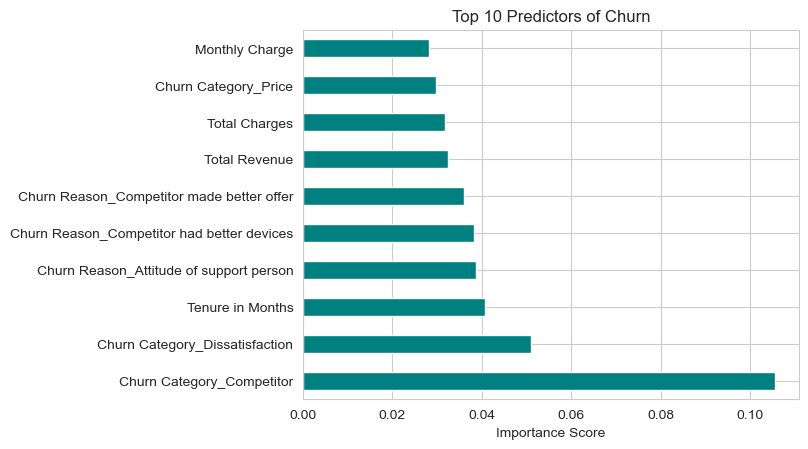

In [30]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Predictors of Churn')
plt.xlabel('Importance Score')
plt.show()

# 4 Generating Probabilities

In [32]:
# 1. Filter the ORIGINAL dataframe for 'Stayed' customers first
results = df[df['Customer Status'] == 'Stayed'].copy()

# 2. Prepare the features for ONLY these specific 'Stayed' customers
# We do this by pulling the same rows (indices) from our model-ready data
X_current = df_model_ready.loc[results.index].drop(columns=['Is_Churned', 'Churn_Value'], errors='ignore')

# 3. Predict probabilities (Now the lengths will match perfectly)
probabilities = model.predict_proba(X_current)[:, 1]

# 4. Add the scores back to your results
results['Churn_Probability_%'] = (probabilities * 100).round(2)

# 5. Sort and display
watchlist = results[['Customer ID', 'Monthly Charge', 'Contract', 'Internet Type', 'Churn_Probability_%']]
watchlist = watchlist.sort_values(by='Churn_Probability_%', ascending=False)

print(f"Alignment Successful! Predicted risk for {len(results)} active customers.")
watchlist.head(10)

Alignment Successful! Predicted risk for 4720 active customers.


,Customer ID,Monthly Charge,Contract,Internet Type,Churn_Probability_%
3185,4566-NECEV,96.55,Month-to-Month,Fiber Optic,40.0
833,1215-VFYVK,48.25,Month-to-Month,Cable,39.0
4564,6435-SRWBJ,82.75,Month-to-Month,Fiber Optic,38.0
1374,2038-OEQZH,86.05,Month-to-Month,Fiber Optic,38.0
4951,6969-MVBAI,90.10,Month-to-Month,Fiber Optic,37.0
5749,8087-LGYHQ,94.05,Month-to-Month,Fiber Optic,37.0
2887,4115-NZRKS,89.15,One Year,Fiber Optic,35.0
2124,3055-MJDSB,24.60,Month-to-Month,DSL,34.0
5198,7315-WYOAW,100.75,Month-to-Month,Fiber Optic,33.0
3379,4815-GBTCD,25.15,Month-to-Month,DSL,33.0


In [33]:
watchlist.to_csv('AI_Powered_Retention_Watchlist.csv', index=False)
print("The AI-enhanced watchlist is ready for the Sales Team!")

The AI-enhanced watchlist is ready for the Sales Team!
